In [1]:
import os
from pathlib import Path

In [6]:
from pathlib import Path

data_dir = Path("./data")

print("Data folder:", data_dir)
print("Exists:", data_dir.exists())
print("Is directory:", data_dir.is_dir())

for item in data_dir.iterdir():
    print(item)

Data folder: data
Exists: True
Is directory: True
data\train
data\val


In [7]:
train_dir = data_dir / "train"

print("Train folder:", train_dir)
print("Exists:", train_dir.exists())

for item in train_dir.iterdir():
    print(item)

Train folder: data\train
Exists: True
data\train\Tomato___Early_blight
data\train\Tomato___healthy
data\train\Tomato___Late_blight


In [12]:
from pathlib import Path

data_dir = Path("./data")
train_dir = data_dir / "train"

for folder in train_dir.iterdir():
    if folder.is_dir():
        images = list(folder.glob("*"))
        print(folder.name, ":", len(images))

Tomato___Early_blight : 800
Tomato___healthy : 1273
Tomato___Late_blight : 1527


In [16]:
from pathlib import Path

data_dir = Path("./data")
train_dir = data_dir / "train"
val_dir = data_dir / "val"

print("TRAIN")
for folder in train_dir.iterdir():
    if folder.is_dir():
        print(folder.name, ":", len(list(folder.glob("*"))), "images")

print("\nVALIDATION")
for folder in val_dir.iterdir():
    if folder.is_dir():
        print(folder.name, ":", len(list(folder.glob("*"))), "images")

TRAIN
Tomato___Early_blight : 800 images
Tomato___healthy : 1273 images
Tomato___Late_blight : 1527 images

VALIDATION
Tomato___Early_blight : 200 images
Tomato___healthy : 318 images
Tomato___Late_blight : 382 images


In [17]:
classes = sorted([
    folder.name
    for folder in train_dir.iterdir()
    if folder.is_dir()
])

print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']
Number of classes: 3


In [18]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    train_dir,
    transform=transform
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=transform
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Classes:", train_dataset.classes)

Training images: 3600
Validation images: 900
Classes: ['Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']


In [19]:
print("Class to index:")
print(train_dataset.class_to_idx)

Class to index:
{'Tomato___Early_blight': 0, 'Tomato___Late_blight': 1, 'Tomato___healthy': 2}


In [20]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 113
Validation batches: 29


In [21]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Labels: tensor([0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 2, 1, 0, 1, 2, 0,
        0, 2, 0, 0, 2, 0, 2, 0])


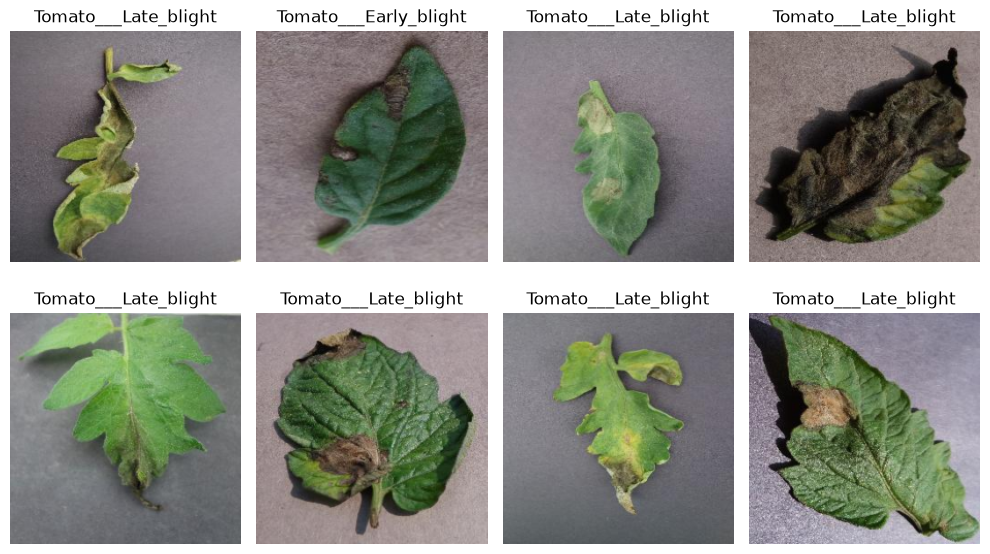

In [22]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)

    image = images[i].permute(1, 2, 0)

    plt.imshow(image)
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [23]:
print("Image shape:", train_dataset[0][0].shape)

Image shape: torch.Size([3, 224, 224])


In [24]:
from collections import Counter

train_labels = [label for _, label in train_dataset]

counts = Counter(train_labels)

for label, count in counts.items():
    print(train_dataset.classes[label], ":", count)

Tomato___Early_blight : 800
Tomato___Late_blight : 1527
Tomato___healthy : 1273


In [25]:
val_labels = [label for _, label in val_dataset]

val_counts = Counter(val_labels)

for label, count in val_counts.items():
    print(val_dataset.classes[label], ":", count)

Tomato___Early_blight : 200
Tomato___Late_blight : 382
Tomato___healthy : 318


In [26]:
print("========== DATASET SUMMARY ==========")
print("Number of classes:", len(train_dataset.classes))
print("Classes:", train_dataset.classes)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Image size: 224 x 224")
print("Channels: RGB")

========== DATASET SUMMARY ==========
Number of classes: 3
Classes: ['Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']
Training images: 3600
Validation images: 900
Training batches: 113
Validation batches: 29
Image size: 224 x 224
Channels: RGB
